<a href="https://colab.research.google.com/github/SakshiWadgaokar/HPC_DL/blob/main/boston1myop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
dataset = pd.read_csv('/content/HousingData.csv')

In [ ]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
dataset.shape

(506, 14)

In [ ]:
dataset.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
dataset = dataset.dropna()

In [ ]:
dataset.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [ ]:
X = dataset.drop('MEDV', axis=1)
y = dataset['MEDV']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(13,)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 564.8546 - mae: 21.8072 - val_loss: 498.4026 - val_mae: 20.9105
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 521.9408 - mae: 20.8359 - val_loss: 452.1270 - val_mae: 19.7915
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 458.0604 - mae: 19.2880 - val_loss: 377.7039 - val_mae: 17.8454
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 351.5851 - mae: 16.3967 - val_loss: 252.3784 - val_mae: 13.9885
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 193.8463 - mae: 11.4553 - val_loss: 104.8152 - val_mae: 7.7318
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 71.8797 - mae: 6.4776 - val_loss: 64.5097 - val_mae: 5.9207
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 47.2918 - mae: 5.3761 - val_loss: 44.1922 - val_mae: 4.6696
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30.8499 - mae: 4.2789 - val_loss: 30.9606 - val_mae: 3.7500
Epoch 9/100
16/16 ━━━

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 21.8049 - mae: 2.5392
Loss: 21.80490493774414
MAE: 2.5391809940338135


In [ ]:
predictions = model.predict(X_test)

print("Predicted Price:", predictions[0])
print("Actual Price:", y_test.iloc[0])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Price: [25.454569]
Actual Price: 25.0


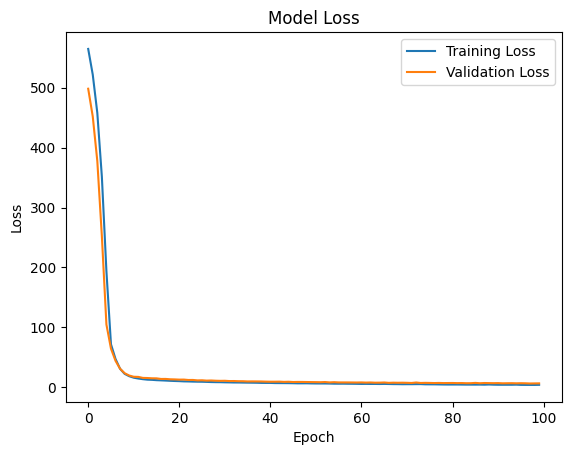

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

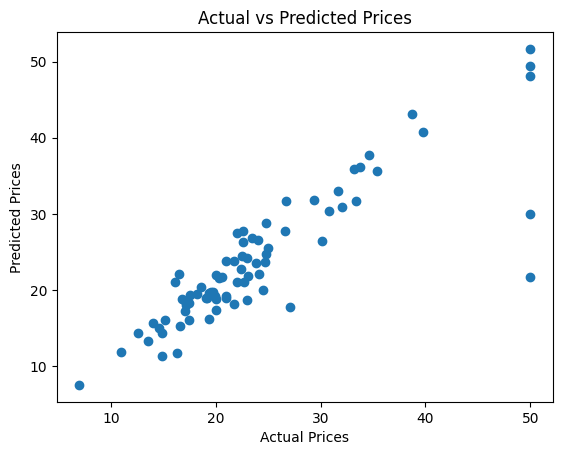

In [ ]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [ ]:
# Theory for Answer Sheet

## Linear Regression using Deep Neural Network for Boston Housing Price Prediction

You can directly write this in your practical file or answer sheet.

---

# Aim

To implement Boston Housing Price Prediction using Linear Regression with Deep Neural Network using TensorFlow and Keras.

---

# Theory

## Introduction

House price prediction is a regression problem where the output is a continuous numerical value. In this experiment, a Deep Neural Network (DNN) is used to predict housing prices using the Boston Housing Dataset.

A Deep Neural Network contains multiple hidden layers that help in learning complex relationships between input features and output values. The model is trained using historical housing data and predicts house prices based on various factors such as crime rate, number of rooms, tax rate, and other housing features.

---

# Boston Housing Dataset

The Boston Housing Dataset contains information collected by the U.S Census Service concerning housing in Boston suburbs.

The dataset contains:

* 506 instances (rows)
* 13 input features
* 1 output feature (house price)

---

# Features of Dataset

Some important features are:

| Feature | Description                        |
| ------- | ---------------------------------- |
| CRIM    | Crime rate                         |
| RM      | Average number of rooms            |
| TAX     | Property tax rate                  |
| PTRATIO | Pupil-teacher ratio                |
| LSTAT   | Lower status population percentage |
| MEDV    | Median house price                 |

---

# Deep Neural Network

A Deep Neural Network is an Artificial Neural Network having multiple hidden layers between input and output layers.

The network used contains:

* Input Layer
* Hidden Layer 1
* Hidden Layer 2
* Hidden Layer 3
* Output Layer

---

# Activation Function

ReLU activation function is used in hidden layers.

ReLU formula:
f(x)=\max(0,x)

It converts negative values into zero and improves training speed.

---

# Loss Function

Mean Squared Error (MSE) is used as loss function.

Formula:
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2

Where:

* ( y_i ) = Actual value
* ( \hat{y}_i ) = Predicted value

MSE calculates the average squared difference between actual and predicted values.

---

# Optimizer

Adam optimizer is used to update neural network weights efficiently during training.

Advantages:

* Faster convergence
* Efficient memory usage
* Adaptive learning rate

---

# Steps Performed

## 1. Import Libraries

Required libraries such as NumPy, Pandas, TensorFlow, Matplotlib, and Scikit-learn are imported.

---

## 2. Load Dataset

Boston Housing dataset is loaded using Pandas.

---

## 3. Data Preprocessing

* Missing values are checked and removed.
* Input and output variables are separated.
* Data is normalized using StandardScaler.

Normalization formula:

genui{"math_block_widget_always_prefetch_v2":{"content":"z=\frac{x-\mu}{\sigma}"}}

---

## 4. Train-Test Split

Dataset is divided into:

* 80% training data
* 20% testing data

---

## 5. Build Neural Network

Sequential model is created using Dense layers.

Architecture:

* 64 neurons
* 32 neurons
* 16 neurons
* 1 output neuron

---

## 6. Compile Model

Model is compiled using:

* Adam optimizer
* MSE loss function
* MAE metric

MAE formula:
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|

---

## 7. Train Model

Model is trained using:

* Epochs = 100
* Batch Size = 16

---

## 8. Evaluate Model

The model performance is evaluated using:

* Loss
* Mean Absolute Error

---

## 9. Predict Prices

The trained model predicts housing prices for testing data.

---

# Result

The Deep Neural Network model was successfully implemented for Boston Housing Price Prediction. The model was trained and evaluated successfully, and predicted housing prices with good accuracy.

---

# Conclusion

Thus, Boston Housing Price Prediction using Deep Neural Network was implemented successfully using TensorFlow and Keras. The model learned the relationship between housing features and house prices effectively and produced accurate predictions.
